In [2]:
import pandas as pd
import numpy as np

### __Part 1__

In [3]:
df1 = pd.read_csv("bike_project_data/weather_copenhagen.csv")
df2 = pd.read_csv("bike_project_data/bike_counts.csv")   
df3 = pd.read_csv("bike_project_data/danish_holidays.csv")
df4 = pd.read_csv("bike_project_data/weekend_dates_2021_2023.csv")

In [4]:
df = pd.merge(df1, df2, on='datetime')
df[["date", "time"]] = df["datetime"].str.split(" ", expand=True)

In [5]:
df["holiday"] = df["date"].isin(df3["date"]).astype(int)
df["weekend"] = (
    df["date"].isin(df4["date"]) & (df["holiday"] == 0)
).astype(int)

<Axes: xlabel='precipitation_mm', ylabel='bike_count'>

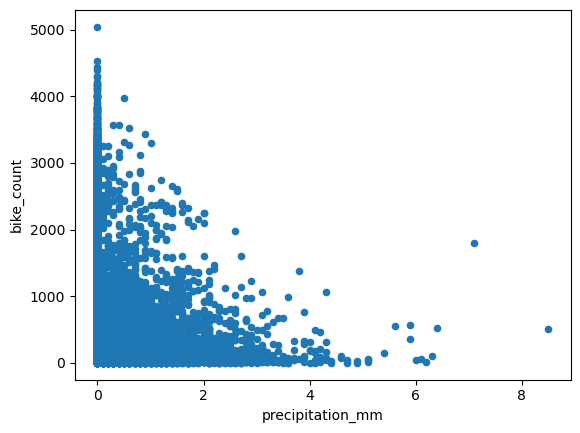

In [6]:
df[df["station"] == "Dronning_Louises_Bro"].plot("precipitation_mm","bike_count","scatter")

In [7]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["day_of_week"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month
df

,datetime,temperature_C,wind_speed_ms,precipitation_mm,station,latitude,longitude,bike_count,date,time,holiday,weekend,day_of_week,month
0,2021-01-01 00:00:00,-2.8,8.7,0.0,Dronning_Louises_Bro,55.6866,12.5640,4.0,2021-01-01,00:00:00,1,0,4,1
1,2021-01-01 00:00:00,-2.8,8.7,0.0,Torvegade,55.6737,12.5862,2.0,2021-01-01,00:00:00,1,0,4,1
2,2021-01-01 00:00:00,-2.8,8.7,0.0,Noerrebrogade,55.6893,12.5530,5.0,2021-01-01,00:00:00,1,0,4,1
3,2021-01-01 00:00:00,-2.8,8.7,0.0,H_C_Andersens_Boulevard,55.6749,12.5697,1.0,2021-01-01,00:00:00,1,0,4,1
4,2021-01-01 00:00:00,-2.8,8.7,0.0,Langebro,55.6688,12.5738,NaN,2021-01-01,00:00:00,1,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157675,2023-12-31 23:00:00,-7.2,0.2,0.1,Torvegade,55.6737,12.5862,2.0,2023-12-31,23:00:00,1,0,6,12
157676,2023-12-31 23:00:00,-7.2,0.2,0.1,Noerrebrogade,55.6893,12.5530,3.0,2023-12-31,23:00:00,1,0,6,12
157677,2023-12-31 23:00:00,-7.2,0.2,0.1,H_C_Andersens_Boulevard,55.6749,12.5697,1.0,2023-12-31,23:00:00,1,0,6,12
157678,2023-12-31 23:00:00,-7.2,0.2,0.1,Langebro,55.6688,12.5738,1.0,2023-12-31,23:00:00,1,0,6,12


In [8]:
missing_values = df.loc[pd.isna(df["bike_count"]) , "weekend"]
missing_indexes = missing_values.index  

In [11]:
df = df.sort_values("datetime").copy()

col = "bike_count"

def fill_nan_same_hour_workdays(group):
    group = group.sort_values("date").copy()
    
    values = group[col].copy()
    
    for i in group.index[group[col].isna()]:
        pos = group.index.get_loc(i)
        
        prev_vals = group.iloc[:pos]
        prev_vals = prev_vals[
            (prev_vals["weekend"] == 0) & (prev_vals[col].notna())
        ][col].tail(5)
        
        next_vals = group.iloc[pos+1:]
        next_vals = next_vals[
            (next_vals["weekend"] == 0) & (next_vals[col].notna())
        ][col].head(5)
        
        neighbors = pd.concat([prev_vals, next_vals])
        
        if len(neighbors) > 0:
            values.loc[i] = neighbors.mean()
    
    group[col] = values
    return group  # <- keeps all columns including station/time

parts = []

for (station, time), group in df.groupby(["station", "time"]):
    filled = fill_nan_same_hour_workdays(group)
    parts.append(filled)

df = pd.concat(parts, ignore_index=True)

df.head()


,datetime,temperature_C,wind_speed_ms,precipitation_mm,station,latitude,longitude,bike_count,date,time,holiday,weekend,day_of_week,month
0,2021-01-01,-2.8,8.7,0.0,Amagerbrogade,55.6627,12.6022,1.0,2021-01-01,00:00:00,1,0,4,1
1,2021-01-02,-10.4,13.9,0.0,Amagerbrogade,55.6627,12.6022,1.0,2021-01-02,00:00:00,0,1,5,1
2,2021-01-03,-12.8,19.3,0.2,Amagerbrogade,55.6627,12.6022,1.0,2021-01-03,00:00:00,0,1,6,1
3,2021-01-04,-5.0,9.1,0.0,Amagerbrogade,55.6627,12.6022,3.0,2021-01-04,00:00:00,0,0,0,1
4,2021-01-05,-7.8,9.4,0.0,Amagerbrogade,55.6627,12.6022,3.0,2021-01-05,00:00:00,0,0,1,1


### __Part 2__

In [12]:
train_df = df[(df["date"] >= "2021-01-01") & (df["date"] <= "2022-06-30")]
val_df = df[(df["date"] >= "2022-07-01") & (df["date"] <= "2022-12-31")]
test_df = df[df["date"] >= "2023-01-01"]

In [13]:
df_louise = train_df[train_df["station"] == "Dronning_Louises_Bro"]
y = df_louise["bike_count"].dropna().values
X = df_louise.drop(columns=["bike_count", "date", "time", "datetime","latitude", "longitude", "station","holiday","weekend"]).values

In [16]:
# OLS formula
beta = np.linalg.inv(X.T @ X) @ X.T @ y

y_pred = X @ beta

residuals = y - y_pred
rss = np.sum(residuals ** 2)
residuals

array([  121.72613195,   416.85264894,   504.82366483, ...,
       -1057.79250283, -1276.45808808,  -828.47922976], shape=(13104,))